Loaded 1652 images. Shape: (1652, 224, 224, 3)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,718,978 (90.48 MB)

 Trainable params: 23,665,858 (90.28 MB)

 Non-trainable params: 53,120 (207.50 KB)

Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 201s 5s/step - accuracy: 0.7955 - loss: 0.5162 - val_accuracy: 0.5811 - val_loss: 56.7799
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 320s 10s/step - accuracy: 0.8750 - loss: 0.3075 - val_accuracy: 0.5811 - val_loss: 13.4373
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 153s 5s/step - accuracy: 0.9015 - loss: 0.2705 - val_accuracy: 0.4189 - val_loss: 3.1201
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 162s 5s/step - accuracy: 0.8902 - loss: 0.2739 - val_accuracy: 0.5811 - val_loss: 1.7786
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 161s 5s/step - accuracy: 0.9318 - loss: 0.1798 - val_accuracy: 0.5811 - val_loss: 2.0918
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 160s 5s/step - accuracy: 0.9706 - loss: 0.0893 - val_accuracy: 0.5811 - val_loss: 2.8514
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 163s 5s/step - accuracy: 0.9536 - loss: 0.1166 - val_accuracy: 0.5811 - val_loss: 5.1459
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 245s 8s/step - accuracy: 0.9848 - loss: 0.0501 - val_accuracy: 0.5811 

c:\Users\markm\anaconda3\envs\env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\markm\anaconda3\envs\env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\markm\anaconda3\envs\env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


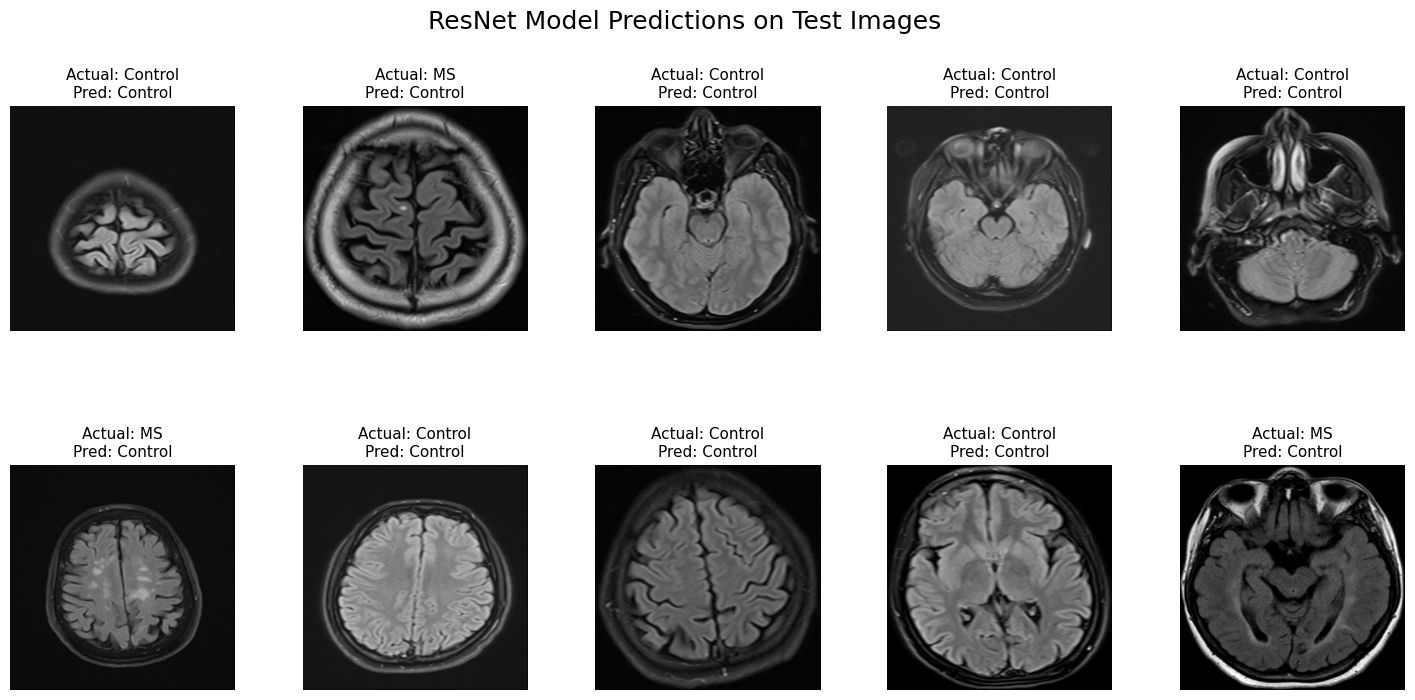

In [3]:
# Transfer Learning for MS Diagnosis using ResNet

# 1. Import Required Libraries
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# 2. Parameters
IMG_SIZE = (224, 224)
DATA_PATH = "../../data/raw/datasets/buraktaci/multiple-sclerosis/versions/1/MS/"
classes = ["Control Axial_crop", "MS Axial_crop"]

# 3. Load images and labels (no augmentation)
def load_images_and_labels(classes, path, img_size):
    images = []
    labels = []
    for label, cat in enumerate(classes):
        image_dir = os.path.join(path, cat)
        for fname in os.listdir(image_dir):
            img_path = os.path.join(image_dir, fname)
            try:
                img = Image.open(img_path).convert('RGB')
                img = img.resize(img_size)
                img_array = np.array(img) / 255.0
                images.append(img_array)
                labels.append(label)
            except Exception as e:
                print(f"Error loading {img_path}: {e}")
    return np.array(images), np.array(labels)

X, y = load_images_and_labels(classes, DATA_PATH, IMG_SIZE)
print(f"Loaded {X.shape[0]} images. Shape: {X.shape}")

# 4. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
y_train_cat = to_categorical(y_train, num_classes=2)
y_test_cat = to_categorical(y_test, num_classes=2)

# 5. Build ResNet50 transfer learning model
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
base_model.trainable = True  # Freeze base

inputs = Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(64, activation='relu')(x)
outputs = Dense(2, activation='softmax')(x)
model = Model(inputs, outputs)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# 6. Train
history = model.fit(
    X_train, y_train_cat,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

# 7. Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test_cat)
print(f"Test accuracy: {test_acc:.2f}")

y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
print(classification_report(y_test, y_pred, target_names=classes))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# 8. Visualize predictions
num_samples = 10
indices = np.random.choice(len(X_test), num_samples, replace=False)
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.subplots_adjust(hspace=0.4, wspace=0.3)
for i, idx in enumerate(indices):
    row = i // 5
    col = i % 5
    img = X_test[idx]
    true_label = "MS" if y_test[idx] == 1 else "Control"
    pred_label = "MS" if y_pred[idx] == 1 else "Control"
    axes[row, col].imshow(img)
    axes[row, col].set_title(f"Actual: {true_label}\nPred: {pred_label}", fontsize=11)
    axes[row, col].axis('off')
plt.suptitle("ResNet Model Predictions on Test Images", fontsize=18)
plt.show()